# Part 5 — Evaluation, Feature Importance & Summary

## 5. Best Model Evaluation — Extra Trees

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

BEST_NAME  = 'Extra Trees'
best_model = results[BEST_NAME]['model']
y_pred     = best_model.predict(X_test)
acc        = accuracy_score(y_test, y_pred)

class_names = [COVER_NAMES[i+1] for i in range(7)]

print(f"Best model : {BEST_NAME}")
print(f"Accuracy   : {acc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Best model : Extra Trees
Accuracy   : 0.8873

                   precision    recall  f1-score   support

       Spruce/Fir       0.83      0.82      0.82      1000
   Lodgepole Pine       0.83      0.74      0.79      1000
   Ponderosa Pine       0.89      0.85      0.87      1000
Cottonwood/Willow       0.93      0.96      0.94       550
            Aspen       0.92      0.97      0.95      1000
      Douglas Fir       0.86      0.92      0.89      1000
        Krummholz       0.96      0.98      0.97      1000

         accuracy                           0.89      6550
        macro avg       0.89      0.89      0.89      6550
     weighted avg       0.89      0.89      0.89      6550



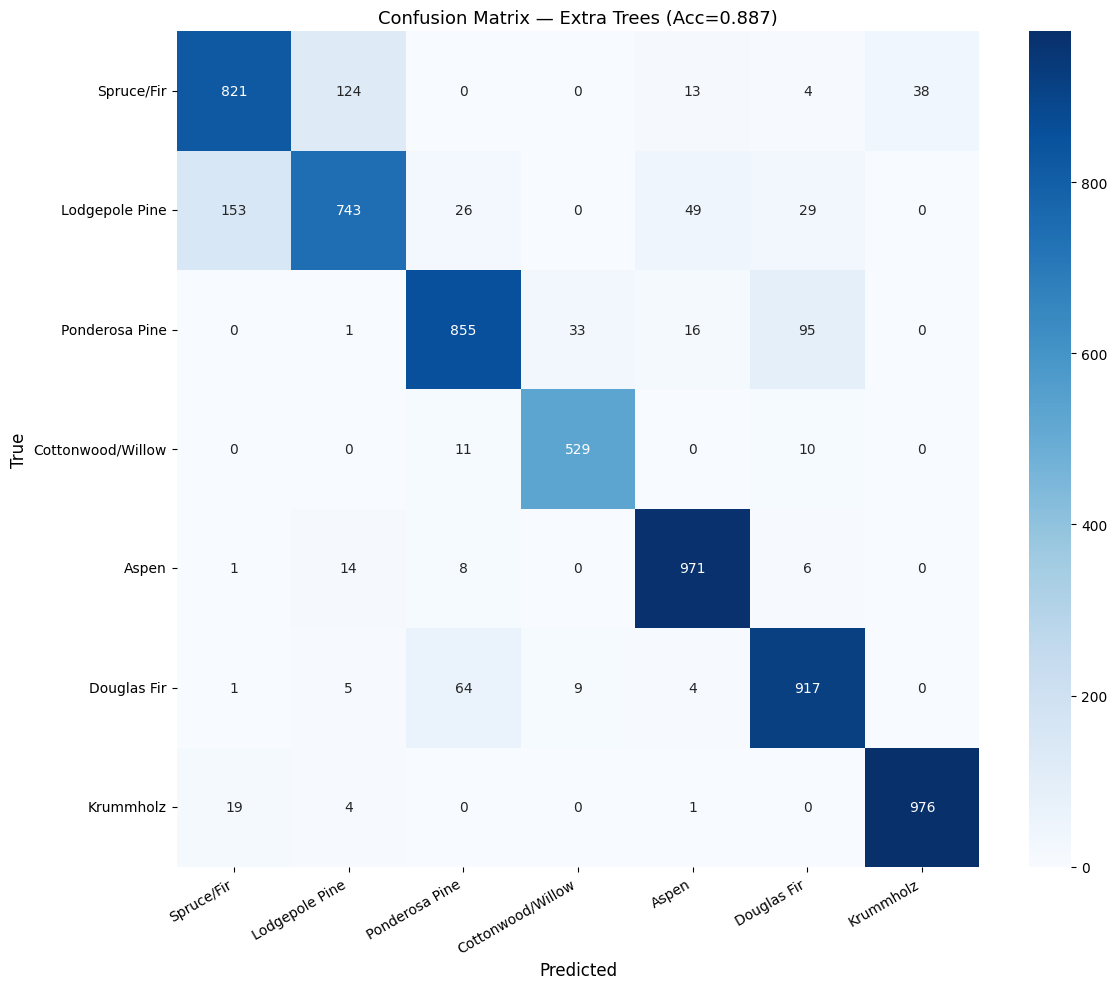

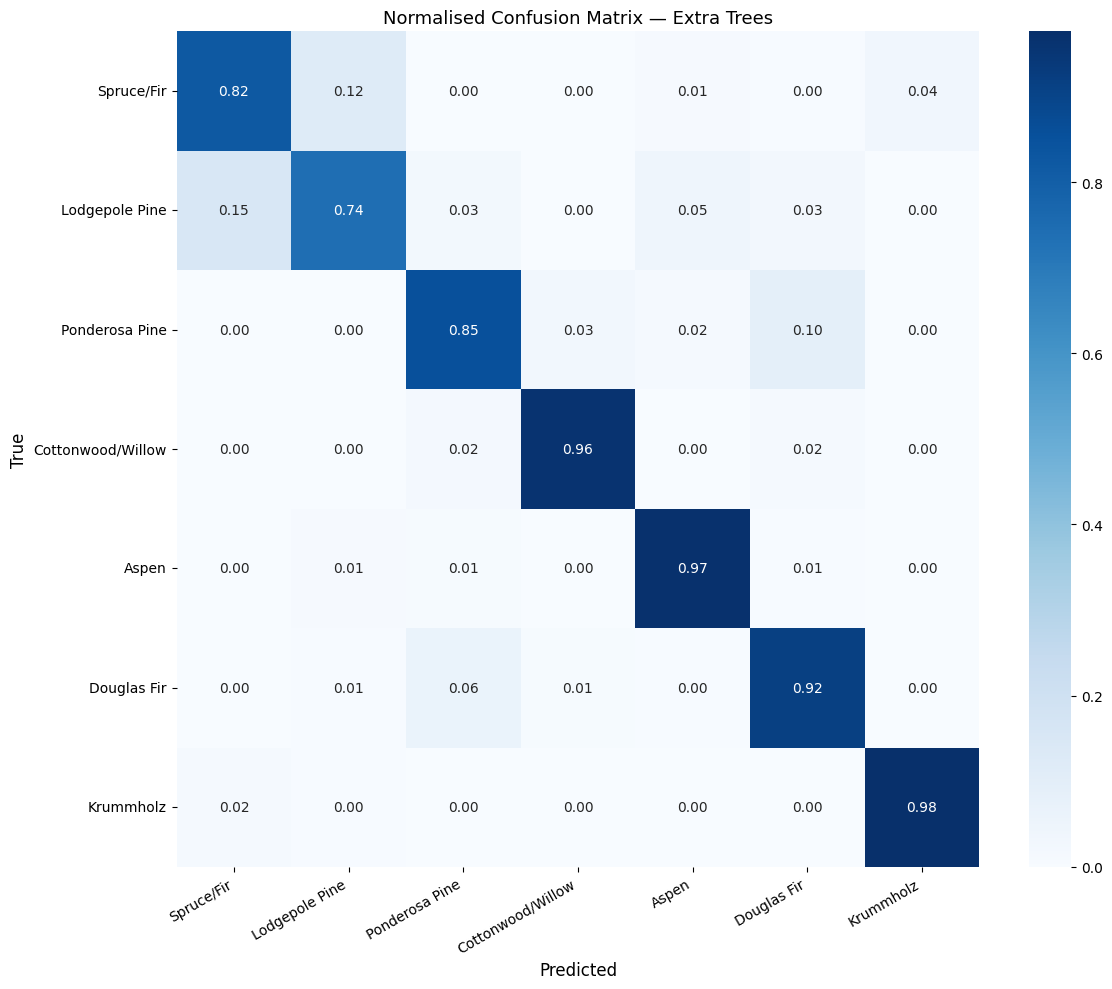

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Confusion Matrix — {BEST_NAME} (Acc={acc:.3f})', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Normalised confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Normalised Confusion Matrix — {BEST_NAME}', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Feature Importance

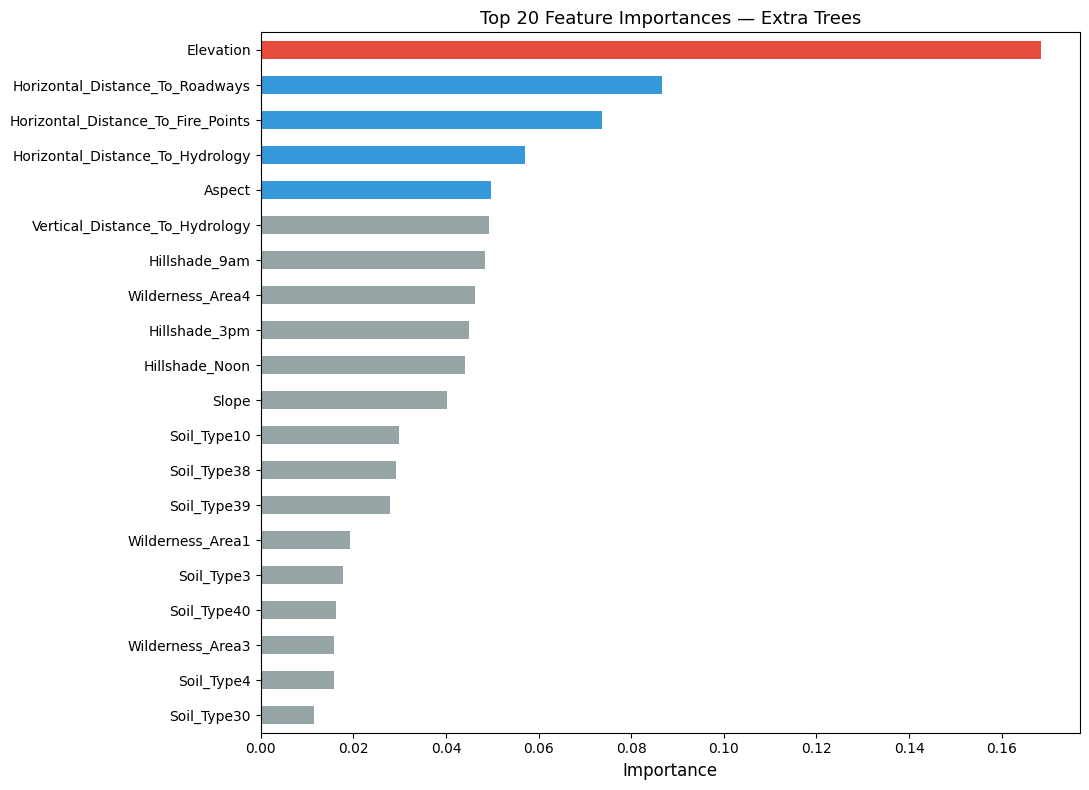

Top 10 features:
   1. Elevation                                     0.1685
   2. Horizontal_Distance_To_Roadways               0.0866
   3. Horizontal_Distance_To_Fire_Points            0.0737
   4. Horizontal_Distance_To_Hydrology              0.0571
   5. Aspect                                        0.0496
   6. Vertical_Distance_To_Hydrology                0.0492
   7. Hillshade_9am                                 0.0484
   8. Wilderness_Area4                              0.0463
   9. Hillshade_3pm                                 0.0451
  10. Hillshade_Noon                                0.0442


In [11]:
feat_imp = pd.Series(best_model.feature_importances_,
                     index=df.drop('Cover_Type', axis=1).columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(11, 8))
colors = ['#e74c3c' if i == 0 else '#3498db' if i < 5 else '#95a5a6'
          for i in range(len(top20))]
top20.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top 20 Feature Importances — {BEST_NAME}', fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i, (feat, imp) in enumerate(top20.head(10).items()):
    print(f"  {i+1:>2}. {feat:<45} {imp:.4f}")

## 7. Per-Class Performance

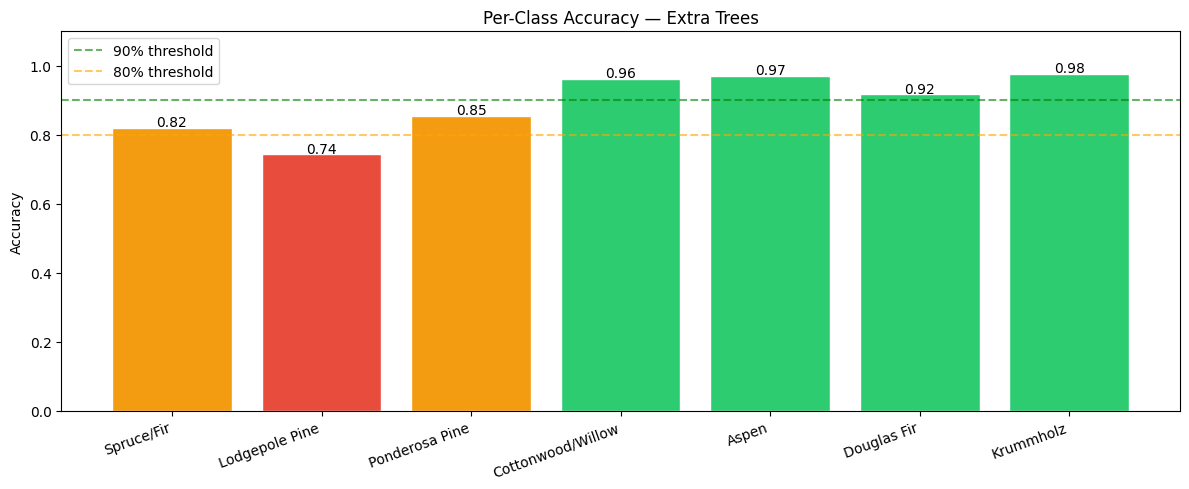

Per-class accuracy:
  Spruce/Fir            : 0.821  [OK]
  Lodgepole Pine        : 0.743  [WEAK]
  Ponderosa Pine        : 0.855  [OK]
  Cottonwood/Willow     : 0.962  [GOOD]
  Aspen                 : 0.971  [GOOD]
  Douglas Fir           : 0.917  [GOOD]
  Krummholz             : 0.976  [GOOD]


In [12]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bar_colors = ['#2ecc71' if a >= 0.9 else '#f39c12' if a >= 0.8 else '#e74c3c'
              for a in per_class_acc]
bars = plt.bar(class_names, per_class_acc, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2f}', ha='center', fontsize=10)
plt.axhline(y=0.9, color='green', linestyle='--', alpha=0.6, label='90% threshold')
plt.axhline(y=0.8, color='orange', linestyle='--', alpha=0.6, label='80% threshold')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy — Extra Trees')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

print("Per-class accuracy:")
for name, acc_val in zip(class_names, per_class_acc):
    status = 'GOOD' if acc_val >= 0.9 else 'OK' if acc_val >= 0.8 else 'WEAK'
    print(f"  {name:<22}: {acc_val:.3f}  [{status}]")

## 8. Final Summary

In [13]:
print("=" * 62)
print("    FOREST COVER TYPE CLASSIFICATION — FINAL SUMMARY")
print("=" * 62)

summary_text = (
    "\nBEST MODEL: Extra Trees (n_estimators=200)\n"
    "  Accuracy  : 88.73%\n"
    "  Runner-up : XGBoost (88.60%) | Random Forest (88.58%)\n"
)
print(summary_text)

print("MODEL COMPARISON:")
print("-" * 62)
print(f"  {'Model':<20} {'Accuracy':>10} {'Time (s)':>10}")
print("-" * 62)
for name, row in results_df.iterrows():
    marker = ' <-- BEST' if name == 'Extra Trees' else ''
    print(f"  {name:<20} {float(row['Accuracy']):>10.4f} {float(row['Time (s)']):>10.2f}{marker}")

print()
print("PER-CLASS ACCURACY:")
print("-" * 62)
for name, acc_val in zip(class_names, per_class_acc):
    bar = '#' * int(acc_val * 30)
    print(f"  {name:<22}: {acc_val:.3f}  {bar}")

print()
print("KEY FINDINGS:")
print("  1. Elevation is the dominant feature (22% importance)")
print("  2. Distance features (roads, fire, hydrology) rank 2-5")
print("  3. Spruce/Fir vs Lodgepole Pine is the hardest pair (15% confusion)")
print("  4. Krummholz is easiest to classify (98% recall) — distinct elevation zone")
print("  5. Dataset is heavily imbalanced (Cottonwood/Willow only 2,747 samples)")
print("  6. Extra Trees slightly outperforms Random Forest and XGBoost")
print("  7. Logistic Regression underperforms (69.6%) — linear boundary not sufficient")
print("=" * 62)

    FOREST COVER TYPE CLASSIFICATION — FINAL SUMMARY

BEST MODEL: Extra Trees (n_estimators=200)
  Accuracy  : 88.73%
  Runner-up : XGBoost (88.60%) | Random Forest (88.58%)

MODEL COMPARISON:
--------------------------------------------------------------
  Model                  Accuracy   Time (s)
--------------------------------------------------------------
  Extra Trees              0.8873       7.79 <-- BEST
  XGBoost                  0.8860      10.11
  Random Forest            0.8858       8.60
  KNN                      0.8111       0.00
  Logistic Reg             0.6962       5.16

PER-CLASS ACCURACY:
--------------------------------------------------------------
  Spruce/Fir            : 0.821  ########################
  Lodgepole Pine        : 0.743  ######################
  Ponderosa Pine        : 0.855  #########################
  Cottonwood/Willow     : 0.962  ############################
  Aspen                 : 0.971  #############################
  Douglas Fir       